In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
#load data
df = pd.read_excel("IndianRailway.xlsx")
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Information:")
df.info()
df.describe()
df.describe(include="object")
df.nunique()
print("Duplicate rows:", df.duplicated().sum())

Dataset Shape: (1900, 13)

Columns:
['train_number', 'train_name', 'station_code', 'station_name', 'average_delay_minutes', 'pct_right_time', 'pct_slight_delay', 'pct_significant_delay', 'pct_cancelled_unknown', 'scraped_at', 'train_number.1', 'train_name.1', 'station_code.1']

First 5 Rows:
   train_number      train_name station_code     station_name  \
0         12673  Cheran Express          MAS  CHENNAI CENTRAL   
1         12673  Cheran Express          AVD            AVADI   
2         12673  Cheran Express          AJJ        ARAKKONAM   
3         12673  Cheran Express          KPD       KATPADI JN   
4         12673  Cheran Express          JTJ      JOLARPETTAI   

   average_delay_minutes  pct_right_time  pct_slight_delay  \
0                    2.0           98.90              0.27   
1                    0.0            0.27              0.00   
2                   16.0           55.34             44.38   
3                   17.0           48.49             49.86   
4     

In [4]:
#data cleaning
print((df["train_number"] == df["train_number.1"]).all())
print((df["train_name"] == df["train_name.1"]).all())
print((df["station_code"] == df["station_code.1"]).all())
df.drop(
    columns=["train_number.1", "train_name.1", "station_code.1"],
    inplace=True
)

True
True
False


In [5]:
#check for missing values
missing = df.isnull().sum()
print("Missing Values:")
print(missing)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage:")
print(missing_percentage.sort_values(ascending=False))

Missing Values:
train_number               0
train_name                 0
station_code               0
station_name               0
average_delay_minutes    236
pct_right_time             0
pct_slight_delay           0
pct_significant_delay      0
pct_cancelled_unknown      0
scraped_at                 0
dtype: int64

Missing Percentage:
average_delay_minutes    12.421053
train_number              0.000000
train_name                0.000000
station_code              0.000000
station_name              0.000000
pct_right_time            0.000000
pct_slight_delay          0.000000
pct_significant_delay     0.000000
pct_cancelled_unknown     0.000000
scraped_at                0.000000
dtype: float64


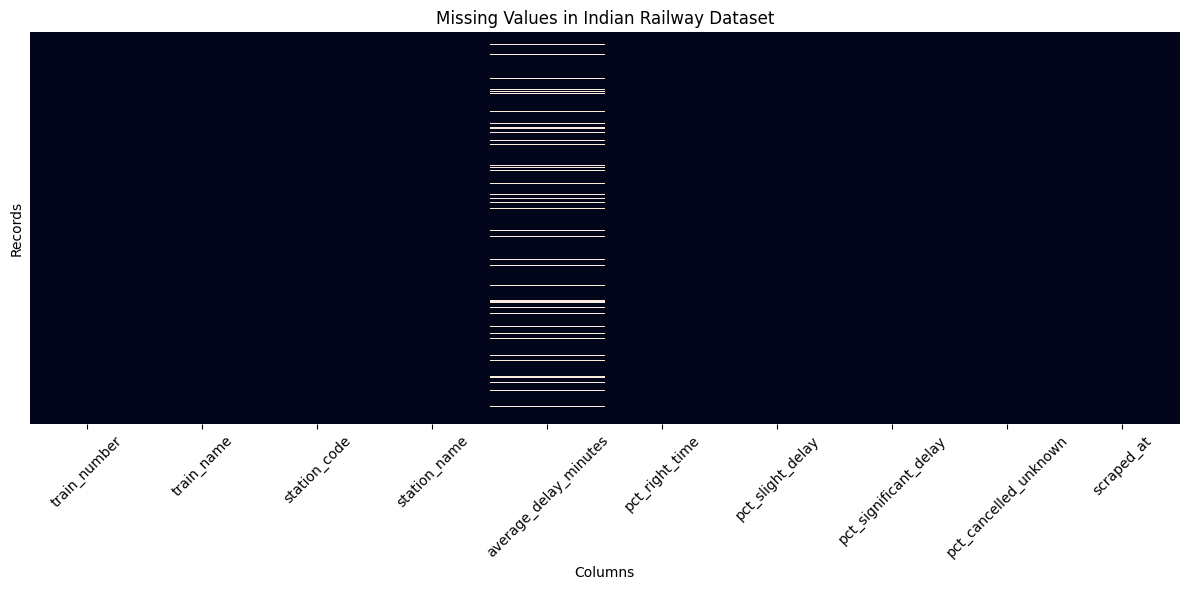

In [6]:
# Missing value heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False
)
plt.title("Missing Values in Indian Railway Dataset")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
#handle missing values
numeric_columns = [
    "average_delay_minutes",
    "pct_right_time",
    "pct_slight_delay",
    "pct_significant_delay",
    "pct_cancelled_unknown"
]
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())


In [9]:
#remove duplicate rows
df.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1900, 10)


In [10]:
#remove duplicate collum
text_columns = [
    "train_name",
    "station_code",
    "station_name"
]
for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

In [12]:
#delay category
def delay_category(minutes):
    if minutes <= 5:
        return "On Time"
    elif minutes <= 15:
        return "Slight Delay"
    elif minutes <= 30:
        return "Moderate Delay"
    else:
        return "High Delay"
df["delay_category"] = df["average_delay_minutes"].apply(delay_category)
df["delay_category"].value_counts()

,count
delay_category,
Moderate Delay,711
High Delay,680
Slight Delay,369
On Time,140


In [13]:
#create Performance score
df["performance_score"] = (
    df["pct_right_time"]
    - df["pct_significant_delay"]
)

In [14]:
df[[
    "train_name",
    "station_name",
    "performance_score"
]].head()

,train_name,station_name,performance_score
0,Cheran Express,CHENNAI CENTRAL,98.90
1,Cheran Express,AVADI,0.27
2,Cheran Express,ARAKKONAM,55.07
3,Cheran Express,KATPADI JN,46.85
4,Cheran Express,JOLARPETTAI,69.59


In [15]:
#How many trains are in the dataset?
total_trains = df["train_number"].nunique()
print("Total Trains:", total_trains)

Total Trains: 90


In [16]:
#How many stations?
total_stations = df["station_code"].nunique()
print("Total Stations:", total_stations)

Total Stations: 480


In [17]:
#Average railway delay
average_delay = df["average_delay_minutes"].mean()
print("Average Delay:", round(average_delay, 2), "minutes")

Average Delay: 38.63 minutes


In [18]:
#Median delay
median_delay = df["average_delay_minutes"].median()
print("Median Delay:", median_delay, "minutes")

Median Delay: 24.0 minutes


In [19]:
#Maximum delay
max_delay = df["average_delay_minutes"].max()
print("Maximum Delay:", max_delay, "minutes")

Maximum Delay: 586.0 minutes


In [20]:
#top 10 most delayed stations
top_10_delayed_stations = (
    df.groupby("station_name")["average_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(top_10_delayed_stations)

station_name
AKOLA JN         429.5
TATANAGAR JN     338.5
BILASPUR JN      299.5
DANKUNI          149.0
RAMPUR HAT       132.0
SAMALKOT JN      126.5
NIDADAVOLU JN    124.0
ANNAVARAM        119.0
TUNI             118.0
ANAKAPALLE       117.0
Name: average_delay_minutes, dtype: float64


In [21]:
#top 10 best performing stations
top_10_best_stations = (
    df.groupby("station_name")["pct_right_time"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(top_10_best_stations)

station_name
PALGHAT TOWN      100.000000
NAGERCOIL JN      100.000000
SABARMATI BG       98.335000
DELHI CANTT        98.335000
CHENNAI EGMORE     97.600000
RANCHI             96.000000
MURI               96.000000
AHMEDABAD JN       96.000000
GURGAON            95.000000
MAMBALAM           94.156667
Name: pct_right_time, dtype: float64


In [23]:
#train-wise analysis average delay by train
train_delay = (
    df.groupby(["train_number", "train_name"])
    ["average_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
)
print(train_delay.head(10))


train_number  train_name          
12261         Howrah Duronto          370.500000
12262         Howrah Duronto          243.625000
12509         Guwahati Sbc Express    131.560976
12839         Howrah Mail             100.828571
12840         Howrah Mail              98.680556
12236         Duronto Express          96.333333
12626         Kerala Express           95.547619
12510         Sbc Guwahati Express     84.775000
12245         Duronto Express          69.166667
12842         Coromandel Express       63.222222
Name: average_delay_minutes, dtype: float64


In [24]:
#top 10 delayed trains:
top_10_trains = train_delay.head(10)
print(top_10_trains)

train_number  train_name          
12261         Howrah Duronto          370.500000
12262         Howrah Duronto          243.625000
12509         Guwahati Sbc Express    131.560976
12839         Howrah Mail             100.828571
12840         Howrah Mail              98.680556
12236         Duronto Express          96.333333
12626         Kerala Express           95.547619
12510         Sbc Guwahati Express     84.775000
12245         Duronto Express          69.166667
12842         Coromandel Express       63.222222
Name: average_delay_minutes, dtype: float64


In [25]:
#Best Punctual Trains
best_trains = (
    df.groupby(["train_number", "train_name"])
    ["pct_right_time"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(best_trains)

train_number  train_name             
12306         Kolkata Rajdhani           100.000000
12049         Gatimaan Express            97.115000
12957         Swarna Jayanti Rajdhani     96.336000
12680         Coimbatore Intercity        93.333077
12313         Sealdah Rajdhani            89.583750
20665         Vande Bharat                88.942500
12434         Rajdhani                    88.890000
12019         Shatabdi                    88.888889
20666         Vande Bharat                87.500000
12010         Shatabdi                    87.111111
Name: pct_right_time, dtype: float64


In [28]:
#Delay Category Analysis
delay_counts = df["delay_category"].value_counts()
print(delay_counts)

#Percentage:
delay_percentage = (
    df["delay_category"]
    .value_counts(normalize=True)* 100
)
print(delay_percentage.round(2))

delay_category
Moderate Delay    711
High Delay        680
Slight Delay      369
On Time           140
Name: count, dtype: int64
delay_category
Moderate Delay    37.42
High Delay        35.79
Slight Delay      19.42
On Time            7.37
Name: proportion, dtype: float64


In [29]:
#Statistical Analysis



#Mean
mean_delay = df["average_delay_minutes"].mean()
print("Mean:", mean_delay)
#Median
median_delay = df["average_delay_minutes"].median()
print("Median:", median_delay)
#Standard deviation
std_delay = df["average_delay_minutes"].std()
print("Standard Deviation:", std_delay)
#Variance
variance_delay = df["average_delay_minutes"].var()
print("Variance:", variance_delay)

Mean: 38.625263157894736
Median: 24.0
Standard Deviation: 47.427399062868574
Variance: 2249.3581818685866


In [30]:
#Quartiles
Q1 = df["average_delay_minutes"].quantile(0.25)
Q2 = df["average_delay_minutes"].quantile(0.50)
Q3 = df["average_delay_minutes"].quantile(0.75)
print("Q1:", Q1)
print("Median:", Q2)
print("Q3:", Q3)

#Interquartile range:
IQR = Q3 - Q1
print("IQR:", IQR)

Q1: 15.0
Median: 24.0
Q3: 44.0
IQR: 29.0


In [31]:
#Detect Outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df["average_delay_minutes"] < lower_bound) |
    (df["average_delay_minutes"] > upper_bound)
]
print("Number of outliers:", len(outliers))

Number of outliers: 200


In [32]:
#Correlation Analysis
correlation = df[numeric_columns].corr()
print(correlation)

#For example:
print(
    df[
        [
            "average_delay_minutes",
            "pct_right_time",
            "pct_slight_delay",
            "pct_significant_delay"
        ]
    ].corr()
)

                       average_delay_minutes  pct_right_time  \
average_delay_minutes               1.000000       -0.544391   
pct_right_time                     -0.544391        1.000000   
pct_slight_delay                    0.004846       -0.703559   
pct_significant_delay               0.790704       -0.607343   
pct_cancelled_unknown               0.026342       -0.147603   

                       pct_slight_delay  pct_significant_delay  \
average_delay_minutes          0.004846               0.790704   
pct_right_time                -0.703559              -0.607343   
pct_slight_delay               1.000000              -0.061465   
pct_significant_delay         -0.061465               1.000000   
pct_cancelled_unknown         -0.120201              -0.066238   

                       pct_cancelled_unknown  
average_delay_minutes               0.026342  
pct_right_time                     -0.147603  
pct_slight_delay                   -0.120201  
pct_significant_delay         

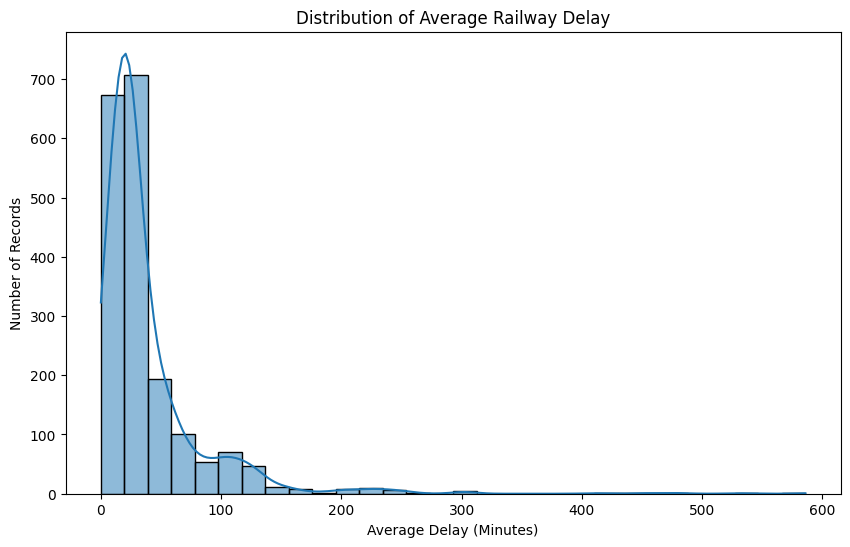

In [33]:
#Delay Distribution
plt.figure(figsize=(10,6))
sns.histplot(
    df["average_delay_minutes"],
    bins=30,
    kde=True
)
plt.title("Distribution of Average Railway Delay")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Number of Records")
plt.show()

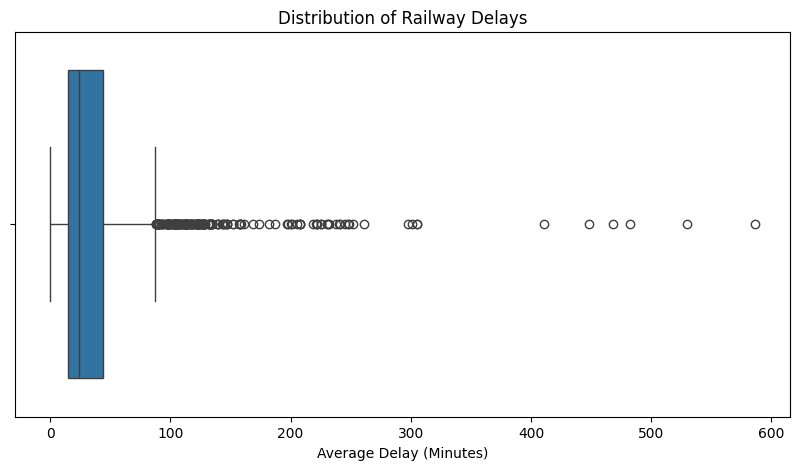

In [34]:
#Detect Outliers
plt.figure(figsize=(10,5))
sns.boxplot(
    x=df["average_delay_minutes"]
)
plt.title("Distribution of Railway Delays")
plt.xlabel("Average Delay (Minutes)")
plt.show()

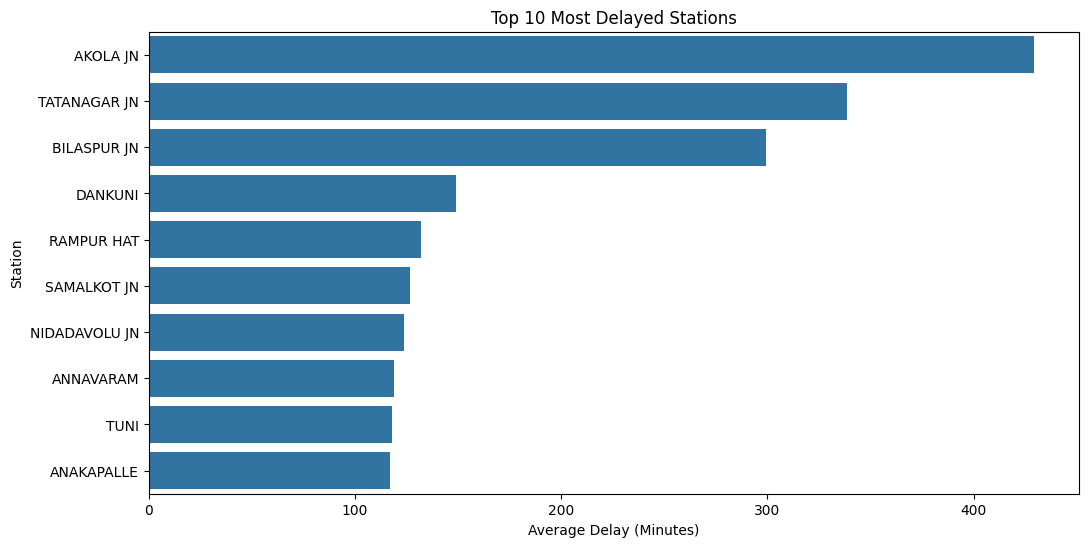

In [35]:
#Top 10 Delayed Stations Bar Chart
top10 = (
    df.groupby("station_name")["average_delay_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top10.values,
    y=top10.index
)
plt.title("Top 10 Most Delayed Stations")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Station")
plt.show()

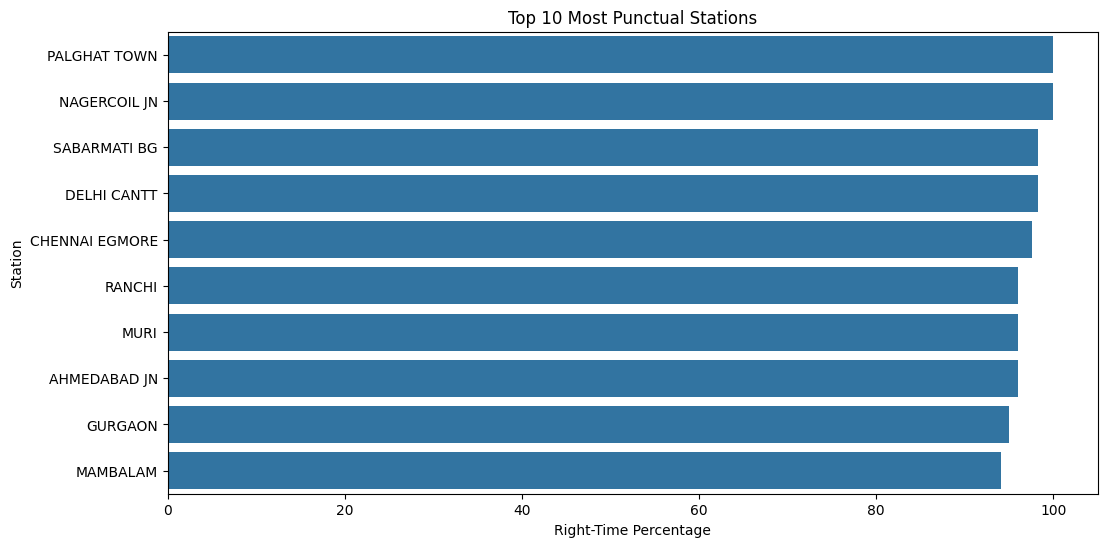

In [36]:
#Top 10 Punctual Stations
top10_punctual = (
    df.groupby("station_name")["pct_right_time"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top10_punctual.values,
    y=top10_punctual.index
)
plt.title("Top 10 Most Punctual Stations")
plt.xlabel("Right-Time Percentage")
plt.ylabel("Station")

plt.show()

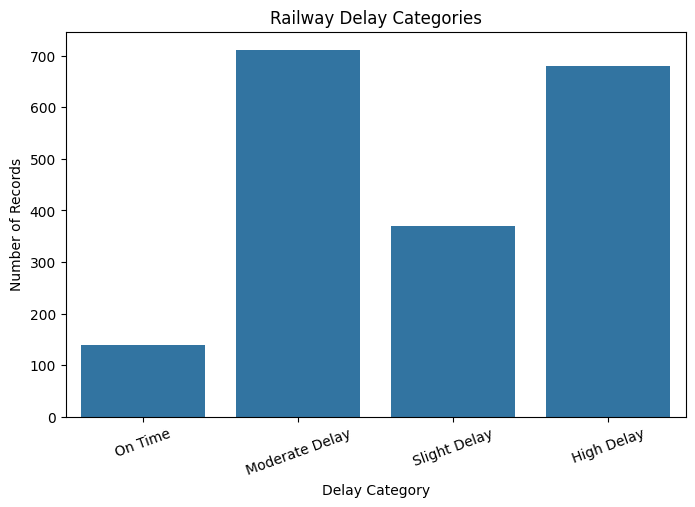

In [37]:
#Delay Category Visualization
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="delay_category"
)
plt.title("Railway Delay Categories")
plt.xlabel("Delay Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=20)
plt.show()

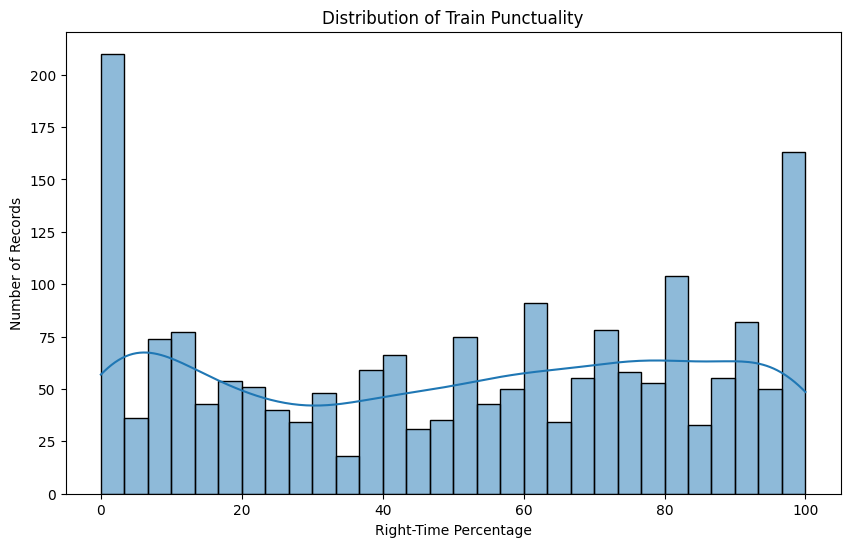

In [38]:
#Punctuality Distribution
plt.figure(figsize=(10,6))
sns.histplot(
    df["pct_right_time"],
    bins=30,
    kde=True
)
plt.title("Distribution of Train Punctuality")
plt.xlabel("Right-Time Percentage")
plt.ylabel("Number of Records")
plt.show()

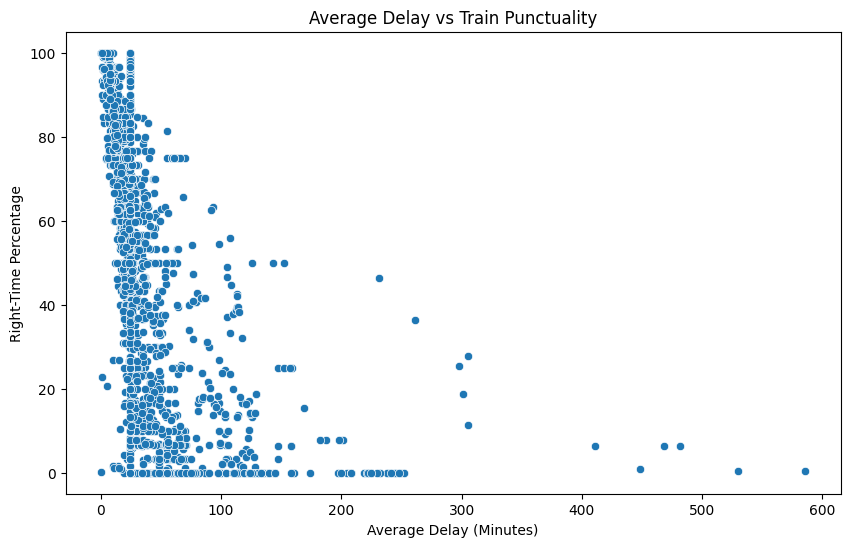

In [39]:
#Delay vs Punctuality
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="average_delay_minutes",
    y="pct_right_time"
)
plt.title("Average Delay vs Train Punctuality")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Right-Time Percentage")

plt.show()

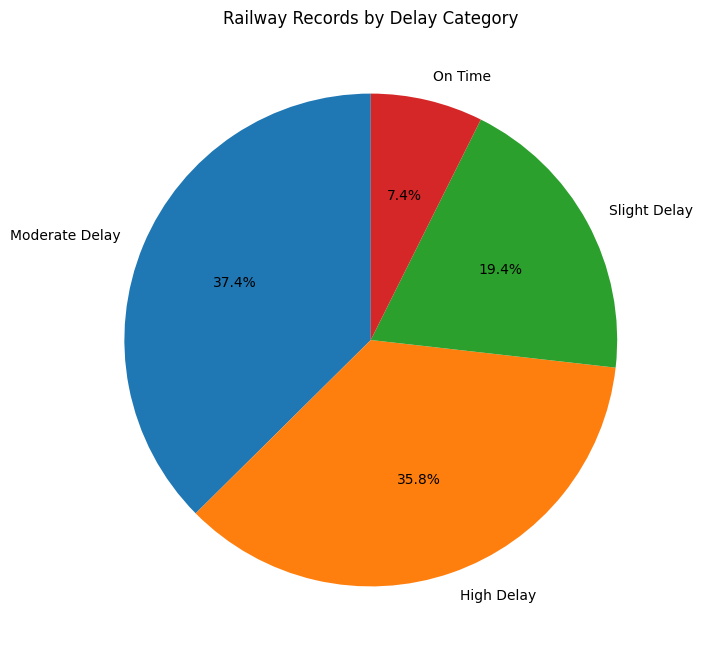

In [40]:
#Pie Chart — Delay Categories
delay_counts = df["delay_category"].value_counts()
plt.figure(figsize=(8,8))
plt.pie(
    delay_counts.values,
    labels=delay_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Railway Records by Delay Category")
plt.show()

In [41]:
df.to_excel(
    "IndianRailway_Cleaned.xlsx",
    index=False
)